In [1]:
import logging
import sys
from pathlib import Path
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

logging.basicConfig(
    format="%(asctime)s.%(msecs)d %(levelname)s %(filename)s:%(lineno)d %(message)s",
    datefmt="%H:%M:%S",
)
logger = logging.getLogger()
logger.setLevel(logging.INFO)


# Move up one level from scripts/ to find the project root
PROJECT_ROOT = Path.cwd().parent.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

logging.info(f"Project root added to path: {PROJECT_ROOT}")

from src.core.feature_engine import SimpleEmbeddingEngine, LegalBertEmbeddingEngine
from src.core.classifier import ClauseClassifier, MODELS_TO_EXPERIMENT
from src.core.clause_processor import process_user_sentence



02:32:47.662 INFO 906847078.py:22 Project root added to path: /home/miguel/enhesa-tos-service
/home/miguel/.cache/pypoetry/virtualenvs/enhesa-tos-service-eiCNO2e5-py3.11/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
#artifacts_exp="simple_embeddings"
artifacts_exp="legal_bert_embeddings"

zip_filepath = PROJECT_ROOT / "data" / "ToS.zip"
artifacts_dir = PROJECT_ROOT / "models" / artifacts_exp
models_output_dir = artifacts_dir / "classifiers"

ARTIFACT_EXPERIMENTS_DICT = {
    "simple_embeddings":SimpleEmbeddingEngine(),
    "legal_bert_embeddings":LegalBertEmbeddingEngine(),
}


02:32:50.473 INFO feature_engine.py:21 Loading SentenceTransformer vector mapping space: all-MiniLM-L6-v2
02:32:50.478 INFO model.py:190 No device provided, using cpu
02:32:50.661 INFO _client.py:1025 HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/modules.json "HTTP/1.1 307 Temporary Redirect"
02:32:50.680 INFO _client.py:1025 HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/sentence-transformers/all-MiniLM-L6-v2/1110a243fdf4706b3f48f1d95db1a4f5529b4d41/modules.json "HTTP/1.1 200 OK"
02:32:50.820 INFO _client.py:1025 HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/config_sentence_transformers.json "HTTP/1.1 307 Temporary Redirect"
02:32:50.841 INFO _client.py:1025 HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/sentence-transformers/all-MiniLM-L6-v2/1110a243fdf4706b3f48f1d95db1a4f5529b4d41/config_sentence_transformers.json "HTTP/1.1 200 OK"
02:32:50.843 INFO

In [3]:
logging.info("Instantiate a fresh engine instance")
search_engine = ARTIFACT_EXPERIMENTS_DICT[artifacts_exp]

logging.info(f"Loading precomputed embeddings from {artifacts_dir}...")
search_engine.load_artifacts(artifacts_dir)


logging.info("Loading pretrained SVC_RBF_Pipeline model...")
clause_clf = ClauseClassifier()
mlp_model_dir = models_output_dir / "SVC_RBF_Pipeline"
clause_clf.load_model(mlp_model_dir)

    

02:32:56.456 INFO 3633428463.py:1 Instantiate a fresh engine instance
02:32:56.457 INFO 3633428463.py:4 Loading precomputed embeddings from /home/miguel/enhesa-tos-service/models/legal_bert_embeddings...
02:32:56.483 INFO feature_engine.py:239 Engine warmed up successfully from disk! Loaded 9414 vectors.
02:32:56.483 INFO 3633428463.py:8 Loading pretrained SVC_RBF_Pipeline model...
02:32:56.484 INFO classifier.py:117 No estimator specified. Defaulting to Balanced Logistic Regression.
02:32:56.497 INFO classifier.py:240 Model framework successfully restored from /home/miguel/enhesa-tos-service/models/legal_bert_embeddings/classifiers/SVC_RBF_Pipeline/clf_estimator.joblib


02:32:56.546 WARNING font_manager.py:1666 findfont: Failed to find font weight semibold, now using 700.


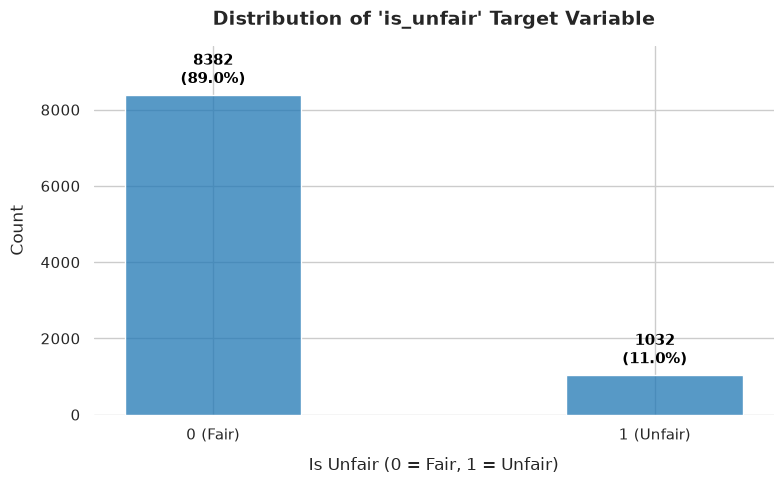

In [4]:
sns.set_theme(style="whitegrid")

total = search_engine.metadata_df['is_unfair'].count()

fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(
    data=search_engine.metadata_df, 
    x='is_unfair', 
    discrete=True,
    color='#1f77b4',
    shrink=0.4,
    ax=ax
)

# Polish labels and titles
plt.title("Distribution of 'is_unfair' Target Variable", fontsize=14, pad=15, fontweight='bold')
plt.xlabel("Is Unfair (0 = Fair, 1 = Unfair)", fontsize=12, labelpad=10)
plt.ylabel("Count", fontsize=12, labelpad=10)

plt.xticks([0, 1], labels=['0 (Fair)', '1 (Unfair)'])

# Add data labels with both counts and percentages on top of the bars
for p in ax.patches:
    height = p.get_height()
    percentage = (height / total) * 100
    ax.annotate(
        f'{int(height)}\n({percentage:.1f}%)', 
        (p.get_x() + p.get_width() / 2., height), 
        ha='center', va='bottom', 
        fontsize=11, fontweight='semibold', color='black',
        xytext=(0, 5), textcoords='offset points'
    )

sns.despine(left=True, bottom=True)

ax.set_ylim(0, ax.get_ylim()[1] * 1.1)

plt.tight_layout()
plt.show()

In [5]:
user_sentence="We may change, suspend, or terminate your access to the platform at our sole discretion, for any reason or no reason, without notice or liability to you."
top_k=3
search_results,is_unfair=process_user_sentence(search_engine,clause_clf,user_sentence,top_k)

02:32:56.604 INFO clause_processor.py:5 Processing input clause: 'We may change, suspend, or terminate your access to the platform at our sole discretion, for any reason or no reason, without notice or liability to you.'
02:32:56.605 INFO clause_processor.py:7 Searching for top 3 similarity matches...
Batches: 100%|██████████| 1/1 [00:00<00:00, 12.64it/s]
02:32:56.724 INFO clause_processor.py:10 Classifying sentence as fair or unfair...
Batches: 100%|██████████| 1/1 [00:00<00:00,  5.76it/s]


In [10]:
for rank, match in enumerate(search_results, 1):
        print(f"Match #{rank} (Similarity Score: {match['similarity_score']:.4f})")
        print(f"Company: {match.get('company', 'Unknown')}")
        print(f"Text: \"{match.get('text')}\"")
        print(f"Historical Ground Truth: {'Unfair' if match.get('is_unfair') == 1 else 'Fair'}")    
        print("-"*20)
if is_unfair == 1:
    print("UNFAIR CLAUSE")
else:
    print("COMPLIANT CLAUSE ")



Match #1 (Similarity Score: 0.9491)
Company: Instagram
Text: "we reserve the right to modify or terminate the service or your access to the service for any reason , without notice , at any time , and without liability to you ."
Historical Ground Truth: Unfair
--------------------
Match #2 (Similarity Score: 0.9488)
Company: Atlas
Text: "you agree that we may , at our sole discretion , suspend or terminate your access to all or part of our website and resources with or without notice and for any reason , including , without limitation , breach of this user agreement ."
Historical Ground Truth: Unfair
--------------------
Match #3 (Similarity Score: 0.9423)
Company: Fitbit
Text: "we reserve the right to suspend or deactivate your account or your access to certain aspects or all of the fitbit service , or to terminate these terms , at our sole discretion , at any time and without notice or liability to you ."
Historical Ground Truth: Unfair
--------------------
UNFAIR CLAUSE
